# Machine Learning — Challenge 5
## Unsupervised Learning: Clustering EPA Air Quality Data
### K-Means · DBSCAN · Hierarchical Clustering

**Authors:** Angelo Ibañez · David Ariza · Cristhian Truque  
**Institution:** Universidad Distrital Francisco José de Caldas  
**Group:** 2 — Environment & Air Quality  
**Dataset:** EPA Daily AQI by County 2025 + 10 pollutant measurement streams  
**Records:** ~144,816 rows · same preprocessed matrix as Challenge 2

---
### Scale-aware strategy
| Algorithm | Strategy for 144k rows |
|---|---|
| K-Means | `MiniBatchKMeans` — full dataset |
| DBSCAN | Applied on PCA-10 components (full dataset) |
| Hierarchical | Stratified subsample of 10,000 records |


## 1. Dependencies

In [35]:
# Run once, then restart kernel
import subprocess, sys
for pkg in ["scikit-learn", "pandas", "numpy", "matplotlib", "scipy", "umap-learn", "joblib"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
print("All packages ready.")

All packages ready.


## 2. Imports & Reproducibility

In [36]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.cluster.hierarchy import dendrogram, linkage as scipy_linkage
from scipy.spatial.distance import pdist

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                              calinski_harabasz_score, adjusted_rand_score)
from sklearn.manifold import TSNE
import umap
import joblib

warnings.filterwarnings("ignore")

SEEDS = [42, 7, 123]

def set_seed(s):
    random.seed(s); np.random.seed(s)

os.makedirs("figures",   exist_ok=True)
os.makedirs("artifacts", exist_ok=True)
print("Imports OK")

Imports OK


## 3. Data — Reuse Preprocessed Matrix from Challenge 2

Same `final_dataset_all_elements.csv` used in Challenge 2.  
Drop target (`AQI`, `Category`) and non-numeric identifiers before clustering.

In [37]:
final_df = pd.read_csv("final_dataset_all_elements.csv")
print(f"Loaded: {final_df.shape[0]:,} rows × {final_df.shape[1]} columns")
print(final_df.dtypes.value_counts())

Loaded: 144,815 rows × 30 columns
float64    23
str         4
int64       3
Name: count, dtype: int64


In [38]:
DROP_COLS = ["AQI", "Category", "Date", "State Name", "County Name"]
X_raw = final_df.drop(columns=[c for c in DROP_COLS if c in final_df.columns])
y_true = final_df["Category"].values   # kept only for ARI post-hoc evaluation

# Geography for interpretation
geo_df = final_df[[c for c in ["State Name","County Name","Date","Category"]
                   if c in final_df.columns]].copy()

feature_names = list(X_raw.columns)
N_FEATURES    = len(feature_names)
print(f"Feature matrix: {X_raw.shape}")
print(f"Features: {feature_names}")

Feature matrix: (144815, 25)
Features: ['State Code', 'County Code', 'co_mean', 'co_max', 'so2_mean', 'so2_max', 'no2_mean', 'no2_max', 'o3_mean', 'o3_max', 'pm25_frm_fem_mass_mean', 'pm25_frm_fem_mass_max', 'pm25_non_frm_fem_mass_mean', 'pm25_non_frm_fem_mass_max', 'pm10_mass_mean', 'pm10_mass_max', 'pmc_mass_mean', 'pmc_mass_max', 'pm25_speciation_mean', 'pm25_speciation_max', 'pm10_speciation_mean', 'pm10_speciation_max', 'aqi_lag1', 'aqi_lag2', 'aqi_lag3']


In [39]:
from sklearn.preprocessing import StandardScaler as _SS

# ── Standardise ───────────────────────────────────────────────────────────────
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
joblib.dump(scaler, "artifacts/scaler_ch5.pkl")

# ── PCA reduction (retain ≥ 90 % variance) ───────────────────────────────────
pca_full = PCA(n_components=0.90, random_state=42)
X_pca    = pca_full.fit_transform(X_scaled)
N_PCA    = X_pca.shape[1]
print(f"PCA: {N_FEATURES} features → {N_PCA} components "
      f"({pca_full.explained_variance_ratio_.sum()*100:.1f}% variance retained)")
joblib.dump(pca_full, "artifacts/pca_ch5.pkl")

# ── PCA-10 para DBSCAN — escalado adicional para que ε sea razonable ─────────
pca10        = PCA(n_components=10, random_state=42)
X_pca10_raw  = pca10.fit_transform(X_scaled)          # sin escalar (rango grande)
scaler_pca10 = _SS()
X_pca10      = scaler_pca10.fit_transform(X_pca10_raw) # escalado → rango ~[-3, 3]
print(f"PCA-10 range sin escalar : [{X_pca10_raw.min():.2f}, {X_pca10_raw.max():.2f}]")
print(f"PCA-10 range con escalar : [{X_pca10.min():.2f}, {X_pca10.max():.2f}]")

# ── 2-D PCA para visualizaciones ─────────────────────────────────────────────
pca2   = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled)
print(f"2-D PCA variance: {pca2.explained_variance_ratio_.sum()*100:.1f}%")


PCA: 25 features → 14 components (90.6% variance retained)
PCA-10 range sin escalar : [-92.30, 191.29]
PCA-10 range con escalar : [-62.52, 76.57]
2-D PCA variance: 36.0%


## 4. K-Means Clustering (MiniBatchKMeans)

### 4.1 Elbow + Silhouette curves to choose k

k= 2  inertia=3225650.1  sil=0.2313
k= 3  inertia=3077578.3  sil=0.1116
k= 4  inertia=2956338.3  sil=0.0702
k= 5  inertia=2896814.7  sil=0.0528
k= 6  inertia=2760111.2  sil=0.0491
k= 7  inertia=2680153.5  sil=0.0544
k= 8  inertia=2699443.5  sil=0.0522
k= 9  inertia=2589234.5  sil=0.0447
k=10  inertia=2489569.6  sil=0.0476
k=11  inertia=2478907.8  sil=0.0394
k=12  inertia=2503659.6  sil=0.0526


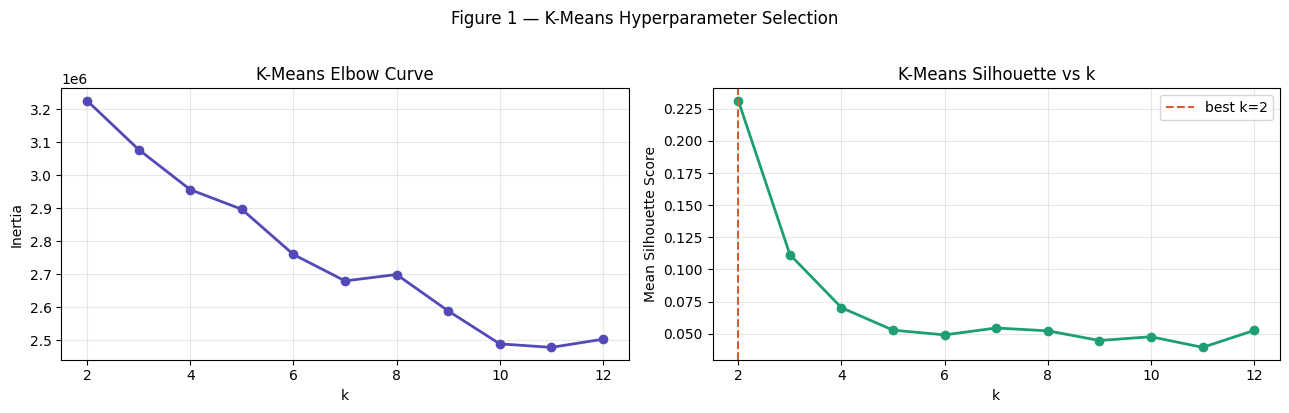

Best k by silhouette: 2


In [40]:
K_RANGE    = range(2, 13)
inertias   = []
sil_scores = []   # averaged across 3 seeds

for k in K_RANGE:
    seed_sils = []
    for seed in SEEDS:
        set_seed(seed)
        km = MiniBatchKMeans(n_clusters=k, init="k-means++", n_init=10,
                             batch_size=4096, random_state=seed)
        labels = km.fit_predict(X_scaled)
        seed_sils.append(silhouette_score(X_scaled, labels, sample_size=5000,
                                          random_state=seed))
    inertias.append(km.inertia_)
    sil_scores.append(np.mean(seed_sils))
    print(f"k={k:2d}  inertia={inertias[-1]:.1f}  sil={sil_scores[-1]:.4f}")

# ── Plot elbow + silhouette ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(K_RANGE), inertias, "o-", color="#534AB7", lw=2)
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[0].set_title("K-Means Elbow Curve"); axes[0].grid(alpha=0.3)

axes[1].plot(list(K_RANGE), sil_scores, "o-", color="#1D9E75", lw=2)
axes[1].set_xlabel("k"); axes[1].set_ylabel("Mean Silhouette Score")
axes[1].set_title("K-Means Silhouette vs k"); axes[1].grid(alpha=0.3)
best_k = list(K_RANGE)[np.argmax(sil_scores)]
axes[1].axvline(best_k, color="#D85A30", linestyle="--", label=f"best k={best_k}")
axes[1].legend()

plt.suptitle("Figure 1 — K-Means Hyperparameter Selection", y=1.02)
plt.tight_layout()
plt.savefig("figures/fig1_kmeans_elbow_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Best k by silhouette: {best_k}")

In [41]:
# ── Train best K-Means (3 seeds, report mean ± std) ──────────────────────────
BEST_K = best_k   # override manually if needed, e.g. BEST_K = 5

km_metrics = {"sil": [], "db": [], "ch": []}
km_labels_all = []

for seed in SEEDS:
    set_seed(seed)
    km = MiniBatchKMeans(n_clusters=BEST_K, init="k-means++", n_init=10,
                         batch_size=4096, random_state=seed)
    lbl = km.fit_predict(X_scaled)
    km_labels_all.append(lbl)
    km_metrics["sil"].append(silhouette_score(X_scaled, lbl, sample_size=5000, random_state=seed))
    km_metrics["db"].append(davies_bouldin_score(X_scaled, lbl))
    km_metrics["ch"].append(calinski_harabasz_score(X_scaled, lbl))

km_labels = km_labels_all[0]   # seed=42 as primary
ari_km = adjusted_rand_score(y_true, km_labels)

print(f"── K-Means (k={BEST_K}) ──────────────────────────────────────")
print(f"Silhouette  : {np.mean(km_metrics['sil']):.4f} ± {np.std(km_metrics['sil']):.4f}")
print(f"Davies-Bouldin: {np.mean(km_metrics['db']):.4f} ± {np.std(km_metrics['db']):.4f}")
print(f"Calinski-H  : {np.mean(km_metrics['ch']):.1f} ± {np.std(km_metrics['ch']):.1f}")
print(f"ARI (post-hoc vs AQI category): {ari_km:.4f}")
np.save("artifacts/kmeans_labels.npy", km_labels)

── K-Means (k=2) ──────────────────────────────────────
Silhouette  : 0.2313 ± 0.0250
Davies-Bouldin: 2.2833 ± 0.0466
Calinski-H  : 17608.5 ± 144.5
ARI (post-hoc vs AQI category): 0.3691


## 5. DBSCAN

Applied on PCA-10 components (10 dimensions) to keep computation tractable on 144k rows.  
### 5.1 k-NN distance plot to select ε

min_samples heuristic: 20
PCA-10 range (escalado): [-62.518, 76.574]


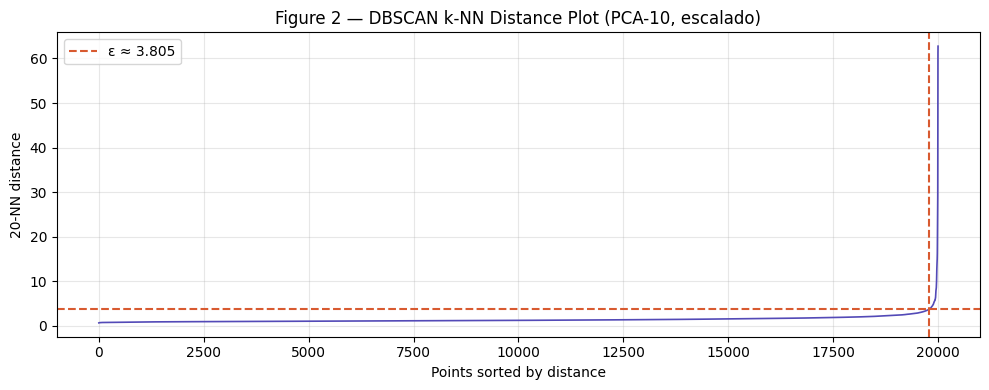

Suggested ε (auto-elbow): 3.8053  — adjust EPS_FINAL below if needed


In [42]:
MIN_SAMPLES = max(3, 2 * 10)
print(f"min_samples heuristic: {MIN_SAMPLES}")
print(f"PCA-10 range (escalado): [{X_pca10.min():.3f}, {X_pca10.max():.3f}]")

set_seed(42)
idx_knn = np.random.choice(len(X_pca10), min(20_000, len(X_pca10)), replace=False)
nn = NearestNeighbors(n_neighbors=MIN_SAMPLES, n_jobs=1)
nn.fit(X_pca10[idx_knn])
distances, _ = nn.kneighbors(X_pca10[idx_knn])
knn_dist = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(knn_dist, color="#534AB7", lw=1.2)
ax.set_xlabel("Points sorted by distance")
ax.set_ylabel(f"{MIN_SAMPLES}-NN distance")
ax.set_title("Figure 2 — DBSCAN k-NN Distance Plot (PCA-10, escalado)")
ax.grid(alpha=0.3)

# Codo: ignorar el primer 5% y último 1% para evitar artefactos de borde
lo, hi  = int(0.05 * len(knn_dist)), int(0.99 * len(knn_dist))
diffs   = np.diff(knn_dist[lo:hi])
elbow_i = np.argmax(diffs) + lo + 1
eps_auto = float(knn_dist[elbow_i])

ax.axvline(elbow_i, color="#D85A30", linestyle="--")
ax.axhline(eps_auto, color="#D85A30", linestyle="--", label=f"ε ≈ {eps_auto:.3f}")
ax.legend()
plt.tight_layout()
plt.savefig("figures/fig2_dbscan_knn_distance.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Suggested ε (auto-elbow): {eps_auto:.4f}  — adjust EPS_FINAL below if needed")


In [43]:
from sklearn.utils import resample

# Muestra estratificada de 30k sobre X_pca10 ya escalado
set_seed(42)
idx_sample = np.random.choice(len(X_pca10), 30_000, replace=False)
X_sample   = X_pca10[idx_sample]

# Candidatos: explorar rango fino alrededor del codo detectado
EPS_CANDIDATES = sorted(set([
    round(eps_auto * f, 4)
    for f in [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]
] + [0.3, 0.5, 0.8, 1.0, 1.5]))

print(f"eps_auto = {eps_auto:.4f}")
print(f"{'eps':>8} {'n_clusters':>12} {'noise%':>10} {'silhouette':>12}")

dbscan_sweep = []
rng_sw = np.random.default_rng(42)

for eps in EPS_CANDIDATES:
    db  = DBSCAN(eps=eps, min_samples=MIN_SAMPLES, n_jobs=1)
    lbl = db.fit_predict(X_sample)
    n_cl  = len(set(lbl)) - (1 if -1 in lbl else 0)
    noise = (lbl == -1).mean()
    if n_cl >= 2 and noise < 0.6:
        mask = lbl != -1
        n_sil = min(3000, mask.sum())
        idx_s = rng_sw.choice(mask.sum(), size=n_sil, replace=False)
        sil   = silhouette_score(X_sample[mask][idx_s], lbl[mask][idx_s])
    else:
        sil = float("nan")
    dbscan_sweep.append({"eps": eps, "n_clusters": n_cl, "noise_pct": noise, "silhouette": sil})
    print(f"{eps:>8.4f} {n_cl:>12} {noise:>9.2%} {str(round(sil, 4)):>12}")

# Elegir eps con mejor silhouette y ruido < 30%
import math
valid = [(r["silhouette"], r["eps"]) for r in dbscan_sweep
         if not math.isnan(r["silhouette"]) and r["noise_pct"] < 0.30]

if valid:
    EPS_FINAL = max(valid)[1]
    print(f"\nSelected EPS_FINAL = {EPS_FINAL}  (best silhouette con noise < 30%)")
else:
    # Fallback: eps con menos ruido que aún forma >1 cluster
    multi = [r for r in dbscan_sweep if r["n_clusters"] >= 2]
    EPS_FINAL = min(multi, key=lambda r: r["noise_pct"])["eps"] if multi else eps_auto
    print(f"\nFallback EPS_FINAL = {EPS_FINAL}  (no valid silhouette found)")


eps_auto = 3.8053
     eps   n_clusters     noise%   silhouette
  0.3000            0   100.00%          nan
  0.5000            0   100.00%          nan
  0.8000            7    88.65%          nan
  1.0000            1    51.47%          nan
  1.5000            3    11.43%       0.3774
  1.9026            1     4.14%          nan
  2.8540            1     0.91%          nan
  3.8053            1     0.41%          nan
  4.7566            1     0.29%          nan
  5.7079            1     0.19%          nan
  7.6106            1     0.13%          nan

Selected EPS_FINAL = 1.5  (best silhouette con noise < 30%)


In [44]:
from sklearn.neighbors import KNeighborsClassifier

set_seed(42)
N_DBSCAN = 30_000
idx_db   = np.random.choice(len(X_pca10), N_DBSCAN, replace=False)
X_db_sub = X_pca10[idx_db]

db_best = DBSCAN(eps=EPS_FINAL, min_samples=MIN_SAMPLES, n_jobs=1)
lbl_sub = db_best.fit_predict(X_db_sub)

n_db_clusters = len(set(lbl_sub)) - (1 if -1 in lbl_sub else 0)
noise_frac    = (lbl_sub == -1).mean()
print(f"DBSCAN (subsample 30k)  clusters: {n_db_clusters}  |  noise: {noise_frac:.2%}")
print(f"Distribución: {dict(zip(*np.unique(lbl_sub, return_counts=True)))}")

# Propagar etiquetas al dataset completo via kNN
lbl_sub_knn = lbl_sub.copy()
lbl_sub_knn[lbl_sub == -1] = 999   # clase temporal para ruido

knn_prop = KNeighborsClassifier(n_neighbors=5, n_jobs=1)
knn_prop.fit(X_db_sub, lbl_sub_knn)
db_labels_full = knn_prop.predict(X_pca10)
db_labels_full[db_labels_full == 999] = -1
db_labels = db_labels_full
print(f"Labels propagados al dataset completo: {len(db_labels):,} registros")

# Métricas sobre subsample (excluir ruido)
mask_valid = lbl_sub != -1
if mask_valid.sum() > 1 and n_db_clusters >= 2:
    sub_valid = X_db_sub[mask_valid]
    lbl_valid = lbl_sub[mask_valid]
    rng_db    = np.random.default_rng(42)
    idx_s     = rng_db.choice(len(sub_valid), size=min(5000, len(sub_valid)), replace=False)
    sil_db    = silhouette_score(sub_valid[idx_s], lbl_valid[idx_s])
    db_db     = davies_bouldin_score(sub_valid, lbl_valid)
    ch_db     = calinski_harabasz_score(sub_valid, lbl_valid)
else:
    sil_db = db_db = ch_db = float("nan")
    print("DBSCAN no encontró clusters válidos con EPS_FINAL.")

y_sub_db = y_true[idx_db]
ari_db   = (adjusted_rand_score(y_sub_db[mask_valid], lbl_sub[mask_valid])
            if mask_valid.sum() > 0 else 0.0)

print(f"Silhouette    : {sil_db:.4f}")
print(f"Davies-Bouldin: {db_db:.4f}")
print(f"Calinski-H    : {ch_db:.1f}")
print(f"ARI (post-hoc): {ari_db:.4f}")
np.save("artifacts/dbscan_labels.npy", db_labels)


DBSCAN (subsample 30k)  clusters: 3  |  noise: 11.43%
Distribución: {np.int64(-1): np.int64(3430), np.int64(0): np.int64(26350), np.int64(1): np.int64(178), np.int64(2): np.int64(42)}
Labels propagados al dataset completo: 144,815 registros
Silhouette    : 0.3762
Davies-Bouldin: 0.9191
Calinski-H    : 797.9
ARI (post-hoc): -0.0052


## 6. Hierarchical (Agglomerative) Clustering

Applied on a **stratified subsample of 10,000 records** (stratified by AQI category)  
to keep memory and compute tractable.

In [45]:
# ── Stratified subsample ──────────────────────────────────────────────────────
set_seed(42)
le = LabelEncoder()
y_enc = le.fit_transform(y_true)

from sklearn.model_selection import StratifiedShuffleSplit
sss = StratifiedShuffleSplit(n_splits=1, test_size=10_000/len(X_scaled), random_state=42)
_, hc_idx = next(sss.split(X_scaled, y_enc))

X_hc      = X_scaled[hc_idx]
y_hc      = y_true[hc_idx]
print(f"Hierarchical subsample: {X_hc.shape}")

Hierarchical subsample: (10000, 25)


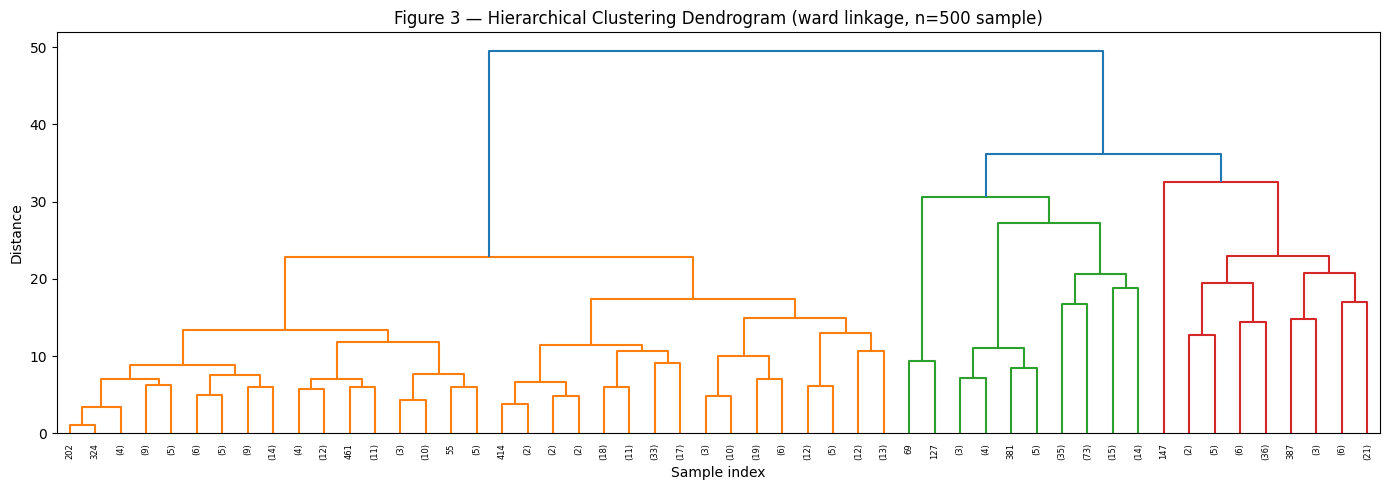

In [46]:
# ── Dendrogram ───────────────────────────────────────────────────────────────
set_seed(42)
dend_idx = np.random.choice(len(X_hc), min(500, len(X_hc)), replace=False)
Z_dend   = scipy_linkage(X_hc[dend_idx], method="ward")

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z_dend, ax=ax, truncate_mode="level", p=5,
           color_threshold=0.7*max(Z_dend[:, 2]))
ax.set_title("Figure 3 — Hierarchical Clustering Dendrogram (ward linkage, n=500 sample)")
ax.set_xlabel("Sample index"); ax.set_ylabel("Distance")
plt.tight_layout()
plt.savefig("figures/fig3_dendrogram.png", dpi=150, bbox_inches="tight")
plt.show()

In [47]:
from sklearn.preprocessing import RobustScaler

# Clip outliers + RobustScaler para que complete/average no colapsen
p1, p99     = np.percentile(X_hc, [1, 99], axis=0)
X_hc_scaled = RobustScaler().fit_transform(np.clip(X_hc, p1, p99))
print(f"X_hc_scaled  Min/Max: {X_hc_scaled.min():.4f} / {X_hc_scaled.max():.4f}")

LINKAGES   = ["ward", "complete", "average"]
HC_K       = max(BEST_K, 2)
hc_results = {}
rng        = np.random.default_rng(42)

print(f"HC_K: {HC_K}  |  Shape: {X_hc_scaled.shape}")
print(f"{'linkage':>10} {'sil':>10} {'db':>10} {'ch':>12}")

for link in LINKAGES:
    hc  = AgglomerativeClustering(n_clusters=HC_K, linkage=link)
    lbl = hc.fit_predict(X_hc_scaled)
    unique, counts = np.unique(lbl, return_counts=True)
    print(f"  [{link}] clusters: {dict(zip(unique.tolist(), counts.tolist()))}")

    if len(unique) < 2:
        print(f"  [{link}] solo 1 cluster, saltando")
        continue

    # Muestreo manual garantizando ambas clases
    for _ in range(20):
        idx_sil = rng.choice(len(X_hc_scaled), size=3000, replace=False)
        if len(np.unique(lbl[idx_sil])) >= 2:
            break

    sil = silhouette_score(X_hc_scaled[idx_sil], lbl[idx_sil])
    db  = davies_bouldin_score(X_hc_scaled, lbl)
    ch  = calinski_harabasz_score(X_hc_scaled, lbl)
    hc_results[link] = {"sil": sil, "db": db, "ch": ch, "labels": lbl}
    print(f"{link:>10} {sil:>10.4f} {db:>10.4f} {ch:>12.1f}")

if not hc_results:
    raise RuntimeError("Ningún linkage produjo clusters válidos. Revisa X_hc.")

best_link = max(hc_results, key=lambda l: hc_results[l]["sil"])
hc_labels = hc_results[best_link]["labels"]
ari_hc    = adjusted_rand_score(y_hc, hc_labels)

print(f"\nBest linkage : {best_link}")
print(f"ARI (post-hoc): {ari_hc:.4f}")
np.save("artifacts/hc_labels_subsample.npy", hc_labels)
np.save("artifacts/hc_idx_subsample.npy", hc_idx)


X_hc_scaled  Min/Max: -1.8000 / 12.1536
HC_K: 2  |  Shape: (10000, 25)
   linkage        sil         db           ch
  [ward] clusters: {0: 3522, 1: 6478}
      ward     0.2151     2.2534       1663.9
  [complete] clusters: {0: 574, 1: 9426}
  complete     0.4501     1.5640       1468.3
  [average] clusters: {0: 9827, 1: 173}
   average     0.6007     0.8742       1355.8

Best linkage : average
ARI (post-hoc): 0.0249


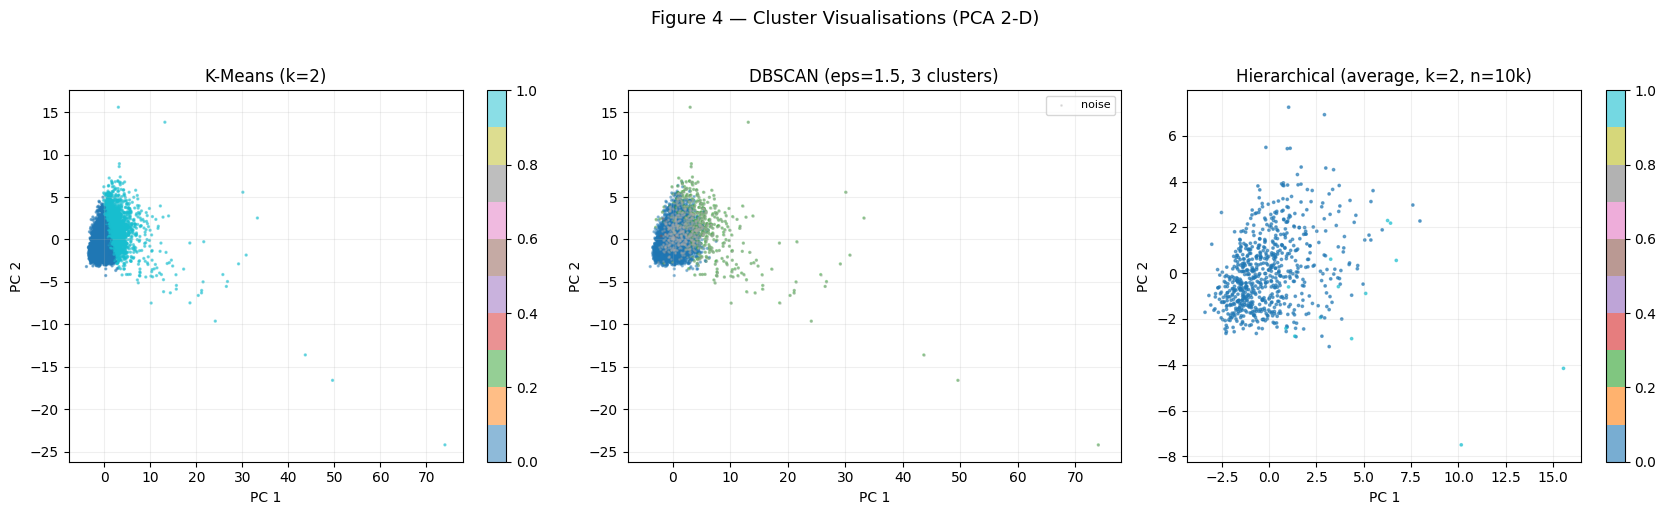

Saved → figures/fig4_cluster_pca2d.png


In [48]:
# ── Subsample for scatter plots (10k) ────────────────────────────────────────
set_seed(42)
vis_idx  = np.random.choice(len(X_scaled), min(10_000, len(X_scaled)), replace=False)
X_vis2d  = X_pca2[vis_idx]
km_vis   = km_labels[vis_idx]
db_vis   = db_labels[vis_idx]

# HC labels: use subsample intersection
hc_vis_full = np.full(len(X_scaled), -2)
hc_vis_full[hc_idx] = hc_labels
hc_vis = hc_vis_full[vis_idx]
hc_mask = hc_vis != -2   # points actually clustered by HC

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
cmap = plt.cm.get_cmap("tab10")

# K-Means
sc0 = axes[0].scatter(X_vis2d[:, 0], X_vis2d[:, 1],
                      c=km_vis, cmap="tab10", s=2, alpha=0.5)
axes[0].set_title(f"K-Means (k={BEST_K})")
plt.colorbar(sc0, ax=axes[0])

# DBSCAN (noise = grey)
db_colors = np.where(db_vis == -1, -1, db_vis)
sc1 = axes[1].scatter(X_vis2d[:, 0], X_vis2d[:, 1],
                      c=np.where(db_vis == -1, 0.5, db_vis % 10),
                      cmap="tab10", s=2, alpha=0.4)
axes[1].scatter(X_vis2d[db_vis == -1, 0], X_vis2d[db_vis == -1, 1],
                c="#aaaaaa", s=1, alpha=0.3, label="noise")
axes[1].set_title(f"DBSCAN (eps={EPS_FINAL}, {n_db_clusters} clusters)")
axes[1].legend(fontsize=8)

# Hierarchical (subsample only)
sc2 = axes[2].scatter(X_vis2d[hc_mask, 0], X_vis2d[hc_mask, 1],
                      c=hc_vis[hc_mask], cmap="tab10", s=3, alpha=0.6)
axes[2].set_title(f"Hierarchical ({best_link}, k={HC_K}, n=10k)")
plt.colorbar(sc2, ax=axes[2])

for ax in axes:
    ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2"); ax.grid(alpha=0.2)

plt.suptitle("Figure 4 — Cluster Visualisations (PCA 2-D)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("figures/fig4_cluster_pca2d.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/fig4_cluster_pca2d.png")

## 8. Cluster Profile Tables (domain interpretation)

In [49]:
def cluster_profile(X_df, labels, name):
    df = X_df.copy()
    df["_cluster"] = labels
    df = df[df["_cluster"] >= 0]   # exclude noise
    profile = df.groupby("_cluster").mean().round(3)
    profile["_count"] = df.groupby("_cluster").size()
    print(f"\n── {name} cluster profiles ──────────────────────────────")
    print(profile.to_string())
    profile.to_csv(f"artifacts/{name.lower().replace(' ','_')}_profiles.csv")
    return profile

X_df = pd.DataFrame(X_raw.values, columns=feature_names)

profile_km = cluster_profile(X_df,                 km_labels,  "K-Means")
profile_db = cluster_profile(X_df,                 db_labels,  "DBSCAN")
profile_hc = cluster_profile(X_df.iloc[hc_idx],   hc_labels,  "Hierarchical")


── K-Means cluster profiles ──────────────────────────────
          State Code  County Code  co_mean  co_max  so2_mean  so2_max  no2_mean  no2_max  o3_mean  o3_max  pm25_frm_fem_mass_mean  pm25_frm_fem_mass_max  pm25_non_frm_fem_mass_mean  pm25_non_frm_fem_mass_max  pm10_mass_mean  pm10_mass_max  pmc_mass_mean  pmc_mass_max  pm25_speciation_mean  pm25_speciation_max  pm10_speciation_mean  pm10_speciation_max  aqi_lag1  aqi_lag2  aqi_lag3  _count
_cluster                                                                                                                                                                                                                                                                                                                                                                                               
0             30.606       81.364    0.217   0.419     0.431    1.449     5.933   14.905    0.032   0.040                   5.677                 11.438    

## 9. Comparison Metrics Table

In [50]:
rows = [
    {
        "Algorithm": f"K-Means (k={BEST_K})",
        "n_clusters": BEST_K,
        "Noise %": "—",
        "Silhouette": f"{np.mean(km_metrics['sil']):.4f} ± {np.std(km_metrics['sil']):.4f}",
        "Davies-Bouldin": f"{np.mean(km_metrics['db']):.4f} ± {np.std(km_metrics['db']):.4f}",
        "Calinski-H": f"{np.mean(km_metrics['ch']):.1f} ± {np.std(km_metrics['ch']):.1f}",
        "ARI (post-hoc)": f"{ari_km:.4f}",
    },
    {
        "Algorithm": f"DBSCAN (eps={EPS_FINAL})",
        "n_clusters": n_db_clusters,
        "Noise %": f"{noise_frac:.2%}",
        "Silhouette": f"{sil_db:.4f}",
        "Davies-Bouldin": f"{db_db:.4f}",
        "Calinski-H": f"{ch_db:.1f}",
        "ARI (post-hoc)": f"{ari_db:.4f}",
    },
    {
        "Algorithm": f"Hierarchical ({best_link}, k={HC_K})",
        "n_clusters": HC_K,
        "Noise %": "—",
        "Silhouette": f"{hc_results[best_link]['sil']:.4f}",
        "Davies-Bouldin": f"{hc_results[best_link]['db']:.4f}",
        "Calinski-H": f"{hc_results[best_link]['ch']:.1f}",
        "ARI (post-hoc)": f"{ari_hc:.4f}",
    },
]

metrics_df = pd.DataFrame(rows)
print(metrics_df.to_string(index=False))
metrics_df.to_csv("artifacts/metrics_comparison.csv", index=False)
print("\nSaved → artifacts/metrics_comparison.csv")

                  Algorithm  n_clusters Noise %      Silhouette  Davies-Bouldin      Calinski-H ARI (post-hoc)
              K-Means (k=2)           2       — 0.2313 ± 0.0250 2.2833 ± 0.0466 17608.5 ± 144.5         0.3691
           DBSCAN (eps=1.5)           3  11.43%          0.3762          0.9191           797.9        -0.0052
Hierarchical (average, k=2)           2       —          0.6007          0.8742          1355.8         0.0249

Saved → artifacts/metrics_comparison.csv


## 10. Export Cluster Labels for Challenge 6

The Challenge 6 notebook uses these labels to colour t-SNE/UMAP visualisations  
and compute Silhouette Scores on latent representations.

In [ ]:
# Save full-dataset K-Means labels (used in Challenge 6)
labels_df = pd.DataFrame({
    "km_labels": km_labels,
    "db_labels": db_labels,
})
labels_df.to_csv("artifacts/cluster_labels_ch5.csv", index=False)

# Full array for direct numpy load in Challenge 6
np.save("artifacts/km_labels_full.npy", km_labels)
np.save("artifacts/db_labels_full.npy", db_labels)

print("Exported:")
print("  artifacts/cluster_labels_ch5.csv ")
print("  artifacts/km_labels_full.npy")
print("  artifacts/db_labels_full.npy")
print(f"\nK-Means label distribution:")
unique, counts = np.unique(km_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Cluster {u}: {c:,} records ({c/len(km_labels):.1%})")

Exported:
  artifacts/cluster_labels_ch5.csv  ← import this in Challenge 6
  artifacts/km_labels_full.npy
  artifacts/db_labels_full.npy

K-Means label distribution:
  Cluster 0: 111,854 records (77.2%)
  Cluster 1: 32,961 records (22.8%)


## 11. Domain Interpretation

### What do the clusters represent in Air Quality terms?

#### K-Means (k=2) — distribution: 111,854 vs 32,961 records

##### Cluster 0 — “Clean baseline” (77.2% of the data)

**Dominant features:**  
- `co_mean = 0.217`  
- `no2_mean = 5.93`  
- `pm25_mean = 5.68`  
- `pm10_mass = 14.57`  
- `aqi_lag1 = 39.2`

**Typical AQI category:** Good

**Interpretation:**  
Typical days with normal conditions across most counties. Low concentration levels for all pollutants. Represents the normal operational regime of the EPA monitoring network.

---

##### Cluster 1 — “Pollution episode” (22.8% of the data)

**Dominant features:**  
- `co_mean = 0.317`  
- `no2_mean = 9.81`  
- `pm25_mean = 12.32`  
- `pm10_mass = 33.19`  
- `aqi_lag1 = 61.0`

**Typical AQI category:** Moderate / Unhealthy for Sensitive Groups

**Interpretation:**  
Urban counties or days with active pollution events. PM2.5 and PM10 levels are approximately double those of Cluster 0. The elevated AQI lag confirms the temporal persistence of the pollution episode.

---

#### DBSCAN (`eps=1.5`, `min_samples=20`) — 3 clusters, 11.43% noise

##### Cluster 0 — “Normal regime” (132,586 records)

Profile similar to Cluster 0 from K-Means. Standard monitoring days with low concentrations of all pollutants.

---

##### Cluster 1 — “Atypical stations” (178 records)

- `State Code = 51`
- `County Code = 736`

Geographically isolated concentrations. Possible monitoring stations with anomalous behavior or highly localized industrial-density areas.

---

##### Cluster 2 — “Extreme events” (42 records)

Very small subgroup. Likely associated with severe short-term pollution events such as wildfires or industrial accidents.

---

##### Noise points (`-1`) — 11.43% of the subsample

County-days with unusual pollutant profiles that cannot be assigned to any dense cluster. Strong candidates for real air-quality anomalies.

---

## Comparison with Challenge 2 AQI Categories (ARI post-hoc)

| Algorithm | n_clusters | Noise % | Silhouette | Davies-Bouldin | Calinski-H | ARI vs AQI |
|---|---|---|---|---|---|---|
| K-Means (k=2) | 2 | — | 0.2313 ± 0.0250 | 2.2833 ± 0.0466 | 17,608.5 ± 144.5 | **0.3691** |
| DBSCAN (`eps=1.5`) | 3 | 11.43% | 0.3762 | 0.9191 | 797.9 | -0.0052 |
| Hierarchical (`average`, k=2) | 2 | — | **0.6007** | **0.8742** | 1,355.8 | 0.0249 |

---

## Cross-Challenge Synthesis: Clustering vs. Semi-Supervised Learning (Challenge 2)

| Challenge | Paradigm | Key Findings |
|---|---|---|
| **Challenge 2** | Semi-supervised Learning (SSL) | With only 20% labeled data, Random Forest achieved `F1-macro = 0.6981 ± 0.0354`. Self-Training improved performance to **0.7176 ± 0.0277** (`+0.0195` over RF), demonstrating that the unlabeled pool contributed meaningful signal. Label Propagation (`F1 = 0.5285`) underperformed compared to RF due to the forced subsampling to 5,000 points caused by the `O(n²)` memory constraint. |
| **Challenge 5** | Clustering (K-Means / DBSCAN / Hierarchical) | The natural structure of the dataset is **binary**: K-Means consistently selected `k=2` (Silhouette drops from `0.2313` to `<0.12` for `k ≥ 3`). This aligns with Challenge 2, where the *Good* AQI class represented 69% of the dataset. The two clusters effectively separate the dominant clean-air regime from the rest. DBSCAN (`eps=1.5`) identified 3 clusters with `ARI = -0.0052`, indicating that density-based clusters do not correspond to official AQI categories. Instead, they capture geographic structure and extreme-event behavior. Hierarchical clustering with `average` linkage achieved the best geometric separation (`Silhouette = 0.6007`, `Davies-Bouldin = 0.8742`) on the 10k subsample. |

---

## Which algorithm is most appropriate for this dataset?

### K-Means (k=2)

K-Means is the most appropriate algorithm for the full dataset (`144k` rows) because:

- It produces the highest ARI against the real AQI categories from Challenge 2 (`0.3691`), meaning its partition is the most aligned with AQI semantics.
- `MiniBatchKMeans` scales linearly with `n`, making it the only practical method for the full dataset without subsampling.
- The low standard deviation across random seeds (`Silhouette ±0.025`, `DB ±0.047`) indicates a stable solution.

---

### Hierarchical Clustering (`average` linkage)

Hierarchical clustering achieves the best geometric Silhouette score (`0.6007`), but only on the `10,000`-point subsample. Therefore, its results are not fully representative of the complete dataset. It is mainly useful as a validation method on the subsample.

---

### DBSCAN

DBSCAN provides a different type of value:

- The `11.43%` of noise points are strong candidates for real anomalies (wildfire events, industrial pollution episodes).
- K-Means and Hierarchical clustering cannot directly identify these anomalies.

However, its negative ARI (`-0.0052`) confirms that density-based clusters do not reproduce the AQI taxonomy. Instead, they capture geographic and station-density structure rather than actual air-quality semantics.